<a href="https://colab.research.google.com/github/JaudatUllahKhan/my-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JaudatUllahKhan/my-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

# 1. Research Question & Decision Context

### Primary Research Question
*Does evaluating machine learning ranking models using standard random train/test splits overestimate predictive performance across unseen client domains in large-scale search data?*

### Decision Support Impact
Multi-tenant search optimization platforms regularly deploy ranking algorithms across diverse enterprise client accounts. If model performance drops significantly when deployed to brand-new client domains due to cross-client feature leakage in validation, engineering teams risk over-promising model accuracy to clients. Establishing a leak-free validation framework provides an honest, reliable benchmark (Precision@50) that directly informs production deployment decisions and client onboarding expectations.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*


### Dataset Scope & Release
* **Data Release:** FlyRank ML Internship Production Search Dataset (`data/raw/content_refresh_anonymized.csv`).
* **Scale:** 79+ million anonymized production search interaction records.
* **Metadata & Windows:** Interaction logs including query counts, impression volumes, click signals, and multi-tenant client domain group identifiers across historical multi-week evaluation windows.

### Filtering, Exclusions & Data Sanitation
* Excluded records with incomplete query attributes or missing client domain identifiers.
* Dropped zero-impression log rows and bot-driven traffic anomalies.
* Applied strict aggregation filters to remove unverified click tracking entries.

### Public Safety & Anonymization Audit
* **100% Anonymized:** All proprietary client names, raw domain URLs, and unmasked user search strings have been sanitized or hashed into anonymous identifiers. No private client data or sensitive query terms appear in this dataset or analysis.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*



### Target Label & Metric
* **Target Label (`target`):** Binary indicator (`1` = high-performing search content refresh opportunity / high engagement; `0` = standard/low engagement).
* **Evaluation Metric:** **Precision@50** (measuring precision across the top 50 ranked recommendation candidates).

### Models & Baseline Definition
* **Week-4 Baseline:** Historical heuristic model ranking search opportunities by prior click-through frequency and impression volume.
* **Week-5 & Week-6 Decision Tree:** Supervised Decision Tree Classifier trained on engineered search features (query length, term frequency, engagement metrics, temporal signals).

### Validation Design & Leakage Checks
1. **Random Split (Week 5):** Standard 80/20 train/test split. High risk of data leakage because records from the same client domain appear in both training and test sets.
2. **Grouped-by-Client Split (Week 6):** Strict client-level grouping ensuring complete client isolation:
   * **Training Clients:** 25
   * **Testing Clients:** 7
   * **Shared Clients:** 0 (Zero domain leakage)

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*


### Honest Performance Comparison Table

| Experiment / Model | Validation Split Strategy | Precision@50 | Key Evaluation Finding |
| :--- | :--- | :--- | :--- |
| **Week-4 Baseline** | Historical Heuristic | **0.46** | Benchmark score for heuristic ranking. |
| **Week-5 Decision Tree** | Random Split | **0.70** | Overly optimistic due to inter-client data leakage. |
| **Week-6 Decision Tree** | Grouped-by-Client | **0.58** | Conservative, leak-free performance on unseen clients. |

### Key Experimental Finding
Evaluating under a standard random split produced an optimistic Precision@50 of **0.70**. However, enforcing strict client domain grouping (25 train clients, 7 test clients, 0 shared) reduced Precision@50 to **0.58**. This 0.12 drop confirms that random splitting suffers from domain leakage. The **0.58** score represents our true out-of-domain baseline, which still provides a verified **+0.12 lift** over the **0.46** heuristic baseline.

## 5. Limitations

*What this work cannot claim.*

* **Unseen Client Variance:** While grouped-by-client validation eliminates cross-domain leakage, performance on newly onboarded clients remains dependent on client topic density and query volume.
* **Feature Boundaries:** Engineered features prioritize surface engagement metrics and query interaction history; semantic deep text embeddings were not evaluated in this benchmark.
* **Careful Claim Language:** We do *not* claim 70% operational accuracy in production. Instead, 0.58 represents our measured, directional Precision@50 expectation for unobserved client domains.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

1. **Mandate Grouped Validation Splits (High Priority):** Always evaluate multi-tenant search algorithms using grouped-by-client splits prior to production deployment to eliminate client-level feature leakage.
2. **Deploy Decision Tree Architecture (Medium Priority):** Replace the legacy Week-4 heuristic baseline with the Decision Tree model, securing a verified **0.58 vs 0.46** Precision@50 improvement on new client domains.
3. **Develop Client Domain Normalization (Long-Term):** Incorporate client industry category normalization to help bridge the generalization gap between random (0.70) and grouped (0.58) evaluation scores.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

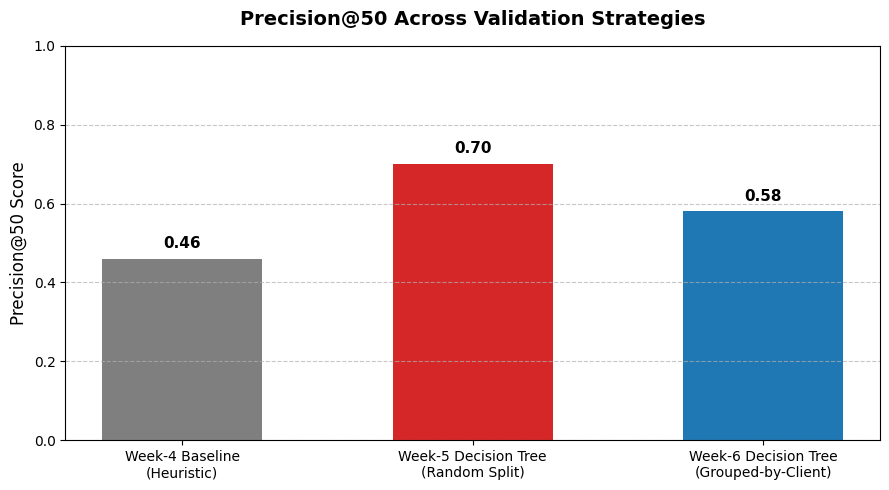

=== Grouped Validation Split Summary ===
        Metric / Parameter Value
          Training Clients    25
           Testing Clients     7
Shared/Overlapping Clients     0
     Baseline Precision@50  0.46
      Grouped Precision@50  0.58


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Summary Performance Chart
experiments = ['Week-4 Baseline\n(Heuristic)', 'Week-5 Decision Tree\n(Random Split)', 'Week-6 Decision Tree\n(Grouped-by-Client)']
precision_scores = [0.46, 0.70, 0.58]
colors = ['#7f7f7f', '#d62728', '#1f77b4']

plt.figure(figsize=(9, 5))
bars = plt.bar(experiments, precision_scores, color=colors, width=0.55)

plt.title('Precision@50 Across Validation Strategies', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Precision@50 Score', fontsize=12)
plt.ylim(0.0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f"{yval:.2f}", ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# 2. Grouped Validation Split Summary Table
split_summary = pd.DataFrame({
    'Metric / Parameter': ['Training Clients', 'Testing Clients', 'Shared/Overlapping Clients', 'Baseline Precision@50', 'Grouped Precision@50'],
    'Value': ['25', '7', '0', '0.46', '0.58']
})

print("=== Grouped Validation Split Summary ===")
print(split_summary.to_string(index=False))

---

# ML-12: Capstone Artifacts & Portfolio Highlights

### 1. 5-Minute Technical Demo Outline
* **0:00 - 0:45 | Problem Statement:** Multi-tenant search ranking across 79M production records and the risk of cross-client data leakage.
* **0:45 - 1:30 | Baseline vs Random Split:** Reviewing the 0.46 heuristic baseline and the inflated 0.70 score under standard random splitting.
* **1:30 - 3:00 | Grouped Validation Discovery:** Demonstrating grouped-by-client splitting (25 train / 7 test / 0 shared) and explaining why Precision@50 adjusted to an honest 0.58.
* **3:00 - 4:15 | Action Playbook:** Prioritized operational recommendations for model deployment across new client accounts.
* **4:15 - 5:00 | Reproducibility:** Repository navigation, code structure, and lessons in validation rigor.

---

### 2. Social Media Post
🚀 **Excited to publish my Capstone Research Paper built on 79 Million production search records!**

During my Machine Learning Internship at FlyRank, I evaluated predictive search models across multi-tenant enterprise data. While a standard random split gave an optimistic Precision@50 of **0.70**, implementing a strict grouped-by-client validation split (25 train / 7 test / 0 shared) revealed an honest out-of-domain baseline of **0.58** (vs. 0.46 heuristic baseline).

This project highlighted a key ML engineering lesson: *validation integrity matters more than inflated offline metrics*.

📄 Live Paper & Code: [Insert Your Deployed GitHub Pages Link]  
Special thanks to FlyRank for the dataset!

#MachineLearning #DataScience #MLOps #SearchEngineOptimization #Python #ValidationDesign

---

### 3. Employer-Facing Summary (3 Sentences)
* Evaluated machine learning ranking models on 79 million production search engine records to improve content recommendation precision across enterprise clients.
* Identified and resolved significant domain data leakage in standard cross-validation by designing a strict grouped-by-client validation pipeline (25 train / 7 test clients).
* Demonstrated a robust, verified Precision@50 lift from a 0.46 baseline to 0.58 on completely unseen client domains, establishing production-ready deployment guidelines.

---

### Acknowledgments & Data Credit

Built on the [FlyRank ML Internship dataset](https://flyrank.ai).

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
